# TMR4240 Project Part 1 – Mandatory Simulations & Checks

This notebook is the one place to **run the four mandatory simulations** from
the project text (*Mandatory Tests and Report*) and to **verify them against
the automated checks**. Each simulation section first runs the scenario —
built exactly as the project text specifies — and produces the plots the
report requires; a check cell below it then verifies the pass/fail criteria.
Once you implement the five templates in `part_1/`, run it top to bottom to
generate your report figures and confirm everything passes.

| Section | Project text | Scenario |
|---|---|---|
| Subsystem checks | *Tips* (sign tests) | current, wind, allocation, controller, reference in isolation |
| Simulation 1 | §8, Simulation 1 | Station keeping: (a) current 0.5 m/s from east; (b) wind 15 m/s mean from east |
| Simulation 2 | §8, Simulation 2 | Current rotating from north to east over 300 s |
| Simulation 3 | §8, Simulation 3 | Setpoint step to $[10, 10, 3\pi/2]$, with and without reference model |
| Simulation 4 | §8, Simulation 4 | Four-corner test |

Each check ends in one of four statuses:

| Status | Meaning |
|---|---|
| `PASS` | all criteria under the check are met |
| `FAIL` | the code ran, but a criterion was not met — the line shows the measured value |
| `NOT IMPLEMENTED` | the template placeholder is still in place |
| `ERROR` | the code crashed or does not follow the template interface |

**On the fresh template** every cell runs, but the vessel barely moves and the
checks report `NOT IMPLEMENTED`: the template controller commands zero thrust
and the environment templates return zero loads. That is expected — implement
`part_1/` block by block and re-run. The same checks also run from the
terminal (`python check.py`) and as the `pytest` suite (what the CI workflow
runs on every push).

Passing everything shows your closed loop **works**; the report is still
graded on analysis, justification, and presentation.

### Setup

Imports and one helper. Note that `DPController()` and `ReferenceModel(dt)`
are built with **default constructors** — the automated checks do the same, so
keep your final tuned parameters as the defaults (see `part_1/controller.py`
and `RefAxisConfig` in `part_1/config.py`).

In [1]:
import sys

sys.path.insert(0, "..")

import matplotlib.pyplot as plt
import numpy as np

from part_1.config import SimConfig, default_thrusters_gunnerus3
from part_1.controller import DPController
from part_1.current import Current
from part_1.wind import Wind
from simulation.simulation_part_1 import DPSimulator3DOF
from simulation.checks import ALL_CHECKS, FAST_CHECKS, run_check, print_result
from simulation.plotter import (plot_time_histories, plot_xy, plot_thrusters,
                                plot_wrench, plot_current, plot_wind)

results = {}  # check results, collected as you go and summarized at the end

print('Project modules imported successfully.')

Project modules imported successfully.


The helper below builds a fresh simulator for every run: the Part 1
configuration (`SimConfig`: dt = 0.05 s, Euler integration, ideal thrusters —
as the project text prescribes for Part 1), your controller, the
three-thruster Gunnerus layout from Table 3 of the project text, and the
reference model when `use_reference=True`.

In [2]:
def run_sim(T, eta_cmd, *, current=None, wind=None, use_reference=True):
    """Build a fresh simulator and run one scenario for T seconds."""
    cfg = SimConfig(T=T, use_reference=use_reference)
    sim = DPSimulator3DOF(cfg, DPController(), default_thrusters_gunnerus3())
    sim.reset_state()
    return sim.run(np.asarray(eta_cmd, dtype=float), current=current, wind=wind)


def setpoint(N=0.0, E=0.0, psi=0.0):
    """6-DOF setpoint vector [N, E, z, phi, theta, psi]."""
    cmd = np.zeros(6)
    cmd[0], cmd[1], cmd[5] = N, E, psi
    return cmd


print('Helper ready.')

Helper ready.


## Subsystem checks — run these first

Frame and sign-convention bugs are the most common DP bugs and the hardest to
see in a full closed-loop plot. These checks exercise each of your five
subsystems **in isolation**, before any simulation — they mirror the sign
tests recommended in the *Tips* section of the project text:

- **current** — "from" convention (*current from east flows west*) and the
  Simulation 2 rotation profile,
- **wind** — load signs at different headings, relative-wind dependence, and
  the slowly-varying component required in Part 1,
- **allocation** — pure surge / sway / yaw wrenches reproduced by
  $B(\alpha)\,u$, thruster limits respected,
- **controller** — NED$\to$BODY rotation of the position error, heading error
  wrapped to $(-\pi, \pi]$ (no $2\pi$ turns),
- **reference model** — smooth step response, no overshoot, heading wrap.

They take a fraction of a second — run them after every change.

In [3]:
for key in FAST_CHECKS:
    results[key] = run_check(key)
    print_result(results[key])
    print()

[     PASS      ] current: direction conventions
                  ok    from east -> flows west: [V_N, V_E] = [0, -0.5]  [got [-0.  -0.5]]
                  ok    components 2-5 of the generalized vector are zero  [got [0. 0. 0. 0.]]
                  ok    rotation start: from north -> [-0.5, 0]  [got [-0.5  0. ]]
                  ok    rotation midpoint: from northeast (towards southwest), speed 0.5  [got [-0.354 -0.354], |v| = 0.500]
                  ok    rotation end: from east -> [0, -0.5]  [got [-0.  -0.5]]

[     PASS      ] wind: load signs and relative wind
                  ok    wind from north at psi=0: surge force Fx < 0  [Fx = -2.86 kN]
                  ok    wind from north at psi=0: |Fy| near zero  [Fy = 0.00 kN vs Fx = -2.86 kN]
                  ok    wind from east at psi=0: sway force Fy < 0 and dominant  [Fx = -0.00 kN, Fy = -10.92 kN]
                  ok    head wind magnitude: Fx = U^2*Cx(180 deg) within 5%  [Fx = -2.86 kN vs expected -2.86 kN]
            

## Simulation 1 — Station Keeping

From the project text: hold the DP setpoint $\eta_{sp} = [0, 0, 0]^\top$ under
two separate environmental conditions, and plot $N(t)$, $E(t)$, $\psi(t)$ and
the $xy$-trajectory for both cases until steady state:

- **(a)** current at 0.5 m/s **from east**, no wind;
- **(b)** wind with average speed 15 m/s **from east** (mean plus a
  slowly-varying component), no current.

Both models are constructed through the documented constructor contract
(`semantics="from"` — see `part_1/current.py` and `part_1/wind.py`). Discuss
in the report: maximum position error, steady-state error, settling time,
heading error, and actuator effort for each case.

Sim 1a: max position deviation 1.07 m, mean over last 100 s 0.00 m


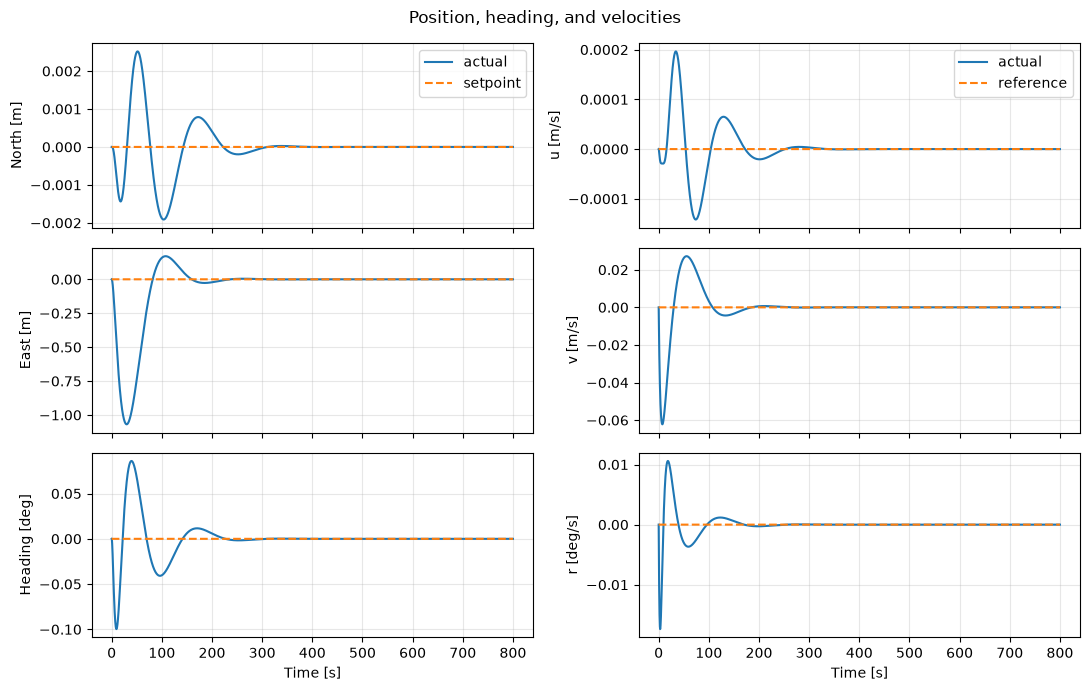

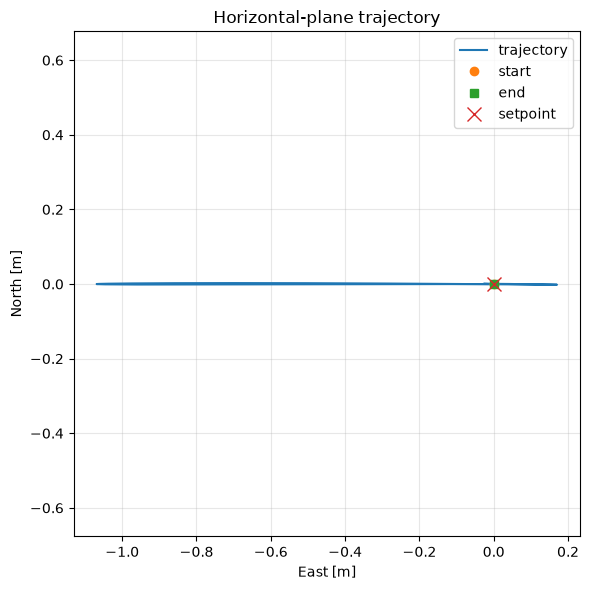

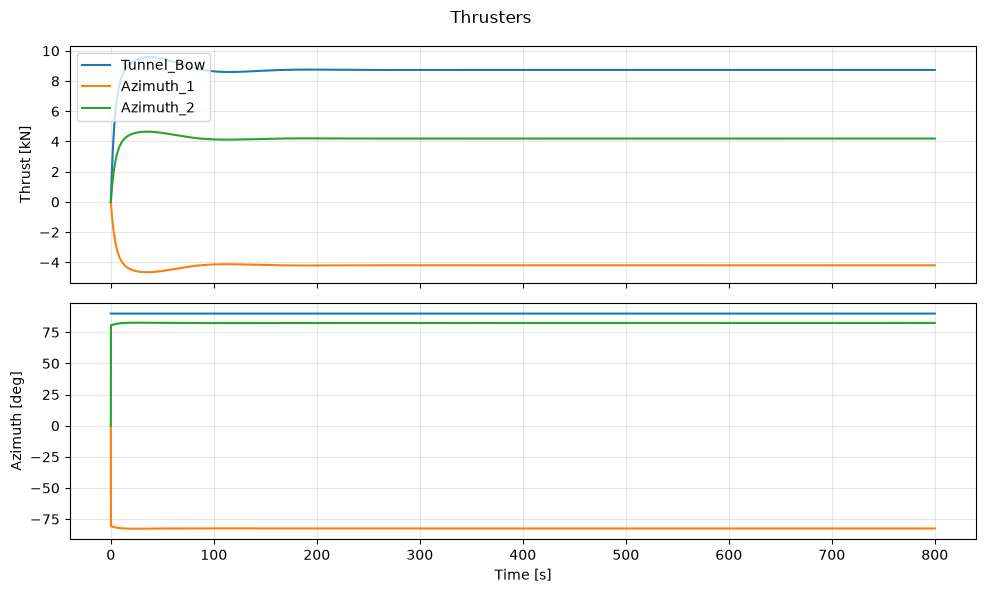

In [4]:
# --- Simulation 1a: current 0.5 m/s from east, no wind ---
current_1a = Current(0.5, np.pi / 2, semantics="from")
logs_1a = run_sim(800.0, setpoint(0, 0, 0), current=current_1a)

plot_time_histories(logs_1a)
plot_xy(logs_1a)
plot_thrusters(logs_1a)   # actuator effort — required in the discussion

pos_err = np.hypot(logs_1a.eta[:, 0], logs_1a.eta[:, 1])
print(f'Sim 1a: max position deviation {pos_err.max():.2f} m, '
      f'mean over last 100 s {pos_err[logs_1a.t >= logs_1a.t[-1] - 100].mean():.2f} m')

Sim 1b: max position deviation 1.55 m, mean over last 100 s 0.21 m


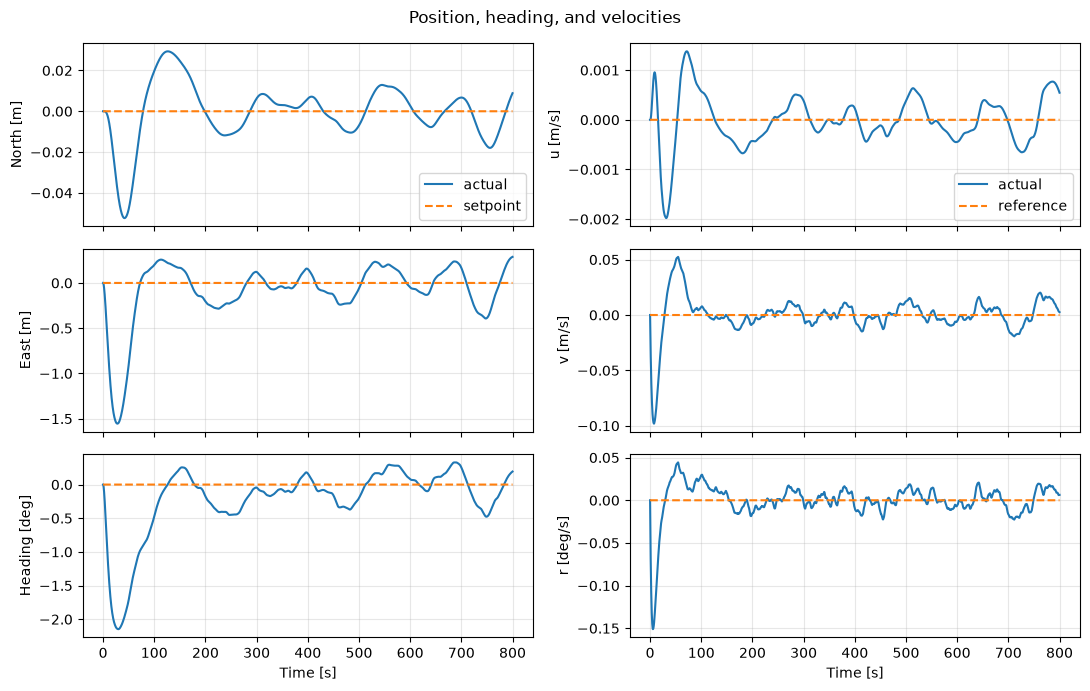

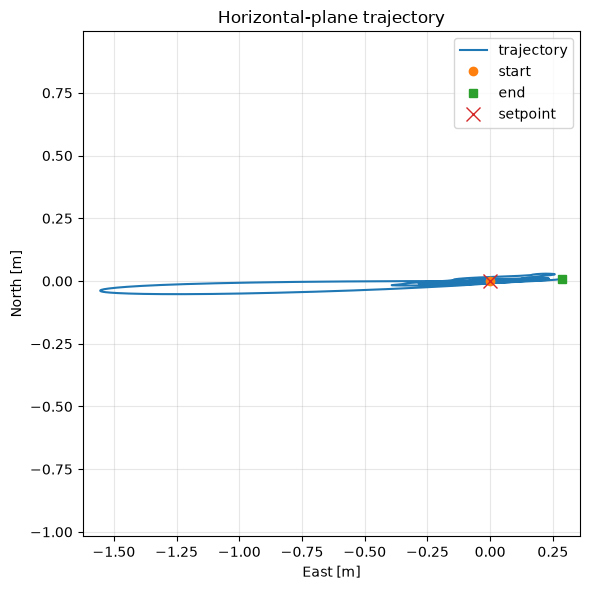

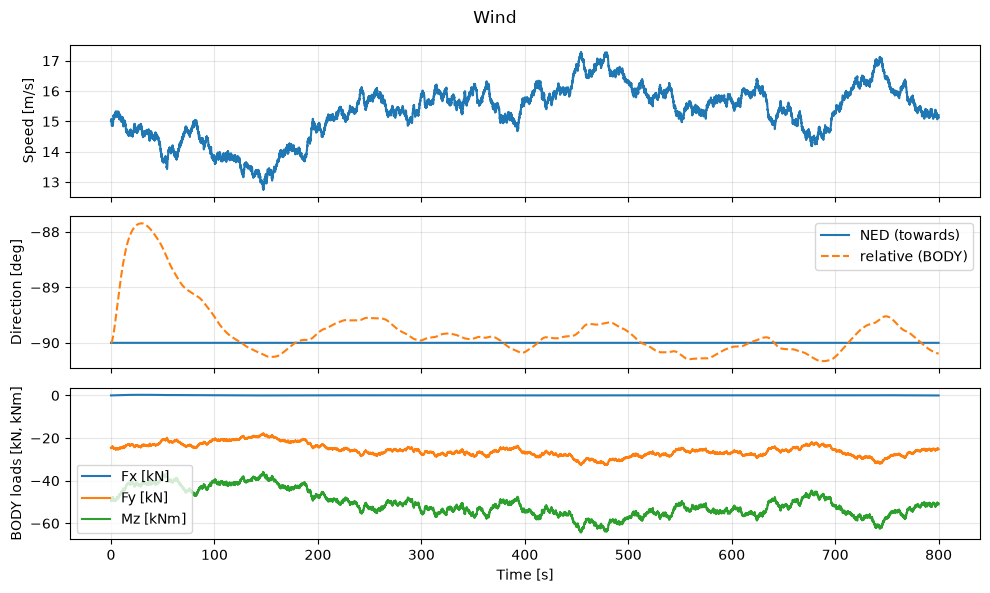

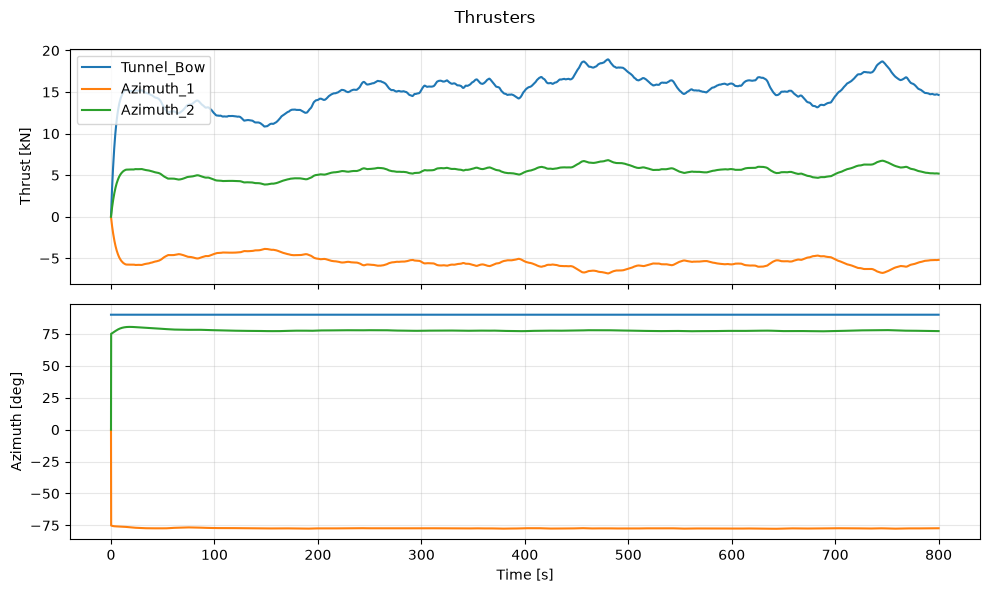

In [5]:
# --- Simulation 1b: wind 15 m/s mean from east, slowly varying, no current ---
# State sigma_slow (and any other wind parameters) in the report and justify them.
wind_1b = Wind(15.0, np.pi / 2, semantics="from", sigma_slow=1.0, seed=0)
logs_1b = run_sim(800.0, setpoint(0, 0, 0), wind=wind_1b)

plot_time_histories(logs_1b)
plot_xy(logs_1b)
plot_wind(logs_1b)        # wind speed / relative angle / loads
plot_thrusters(logs_1b)

pos_err = np.hypot(logs_1b.eta[:, 0], logs_1b.eta[:, 1])
print(f'Sim 1b: max position deviation {pos_err.max():.2f} m, '
      f'mean over last 100 s {pos_err[logs_1b.t >= logs_1b.t[-1] - 100].mean():.2f} m')

In [6]:
# Pass/fail criteria for Simulation 1 (the check re-runs each scenario with
# your default-constructed classes)
for key in ("sim1_current", "sim1_wind"):
    results[key] = run_check(key)
    print_result(results[key])
    print()

[     PASS      ] Simulation 1a: station keeping in current (0.5 m/s from east)
                  ok    all states finite (no NaN)
                  ok    max position deviation < 5 m  [max 1.07 m]
                  ok    steady-state position error < 1.0 m (last 100 s)  [mean 0.00 m]
                  ok    steady-state heading error < 3 deg  [mean 0.00 deg]

[     PASS      ] Simulation 1b: station keeping in wind (15 m/s from east)
                  ok    all states finite (no NaN)
                  ok    max position deviation < 5 m  [max 1.55 m]
                  ok    steady-state position error < 1.0 m (last 100 s)  [mean 0.21 m]
                  ok    steady-state heading error < 3 deg  [mean 0.22 deg]



## Simulation 2 — Rotating Current

From the project text: no wind; the current varies linearly from
0.5 m/s **from north** to 0.5 m/s **from east** over 300 s while the vessel
holds the origin — the *direction* rotates at constant speed. Run longer than
the transition to reach steady state, and plot position, heading, **and the
current input** (the constructor's `beta_end`/`duration` arguments implement
the rotation — see `part_1/current.py`).

Discuss how the controller reacts during the 300-second transition and after
the current direction stabilises.

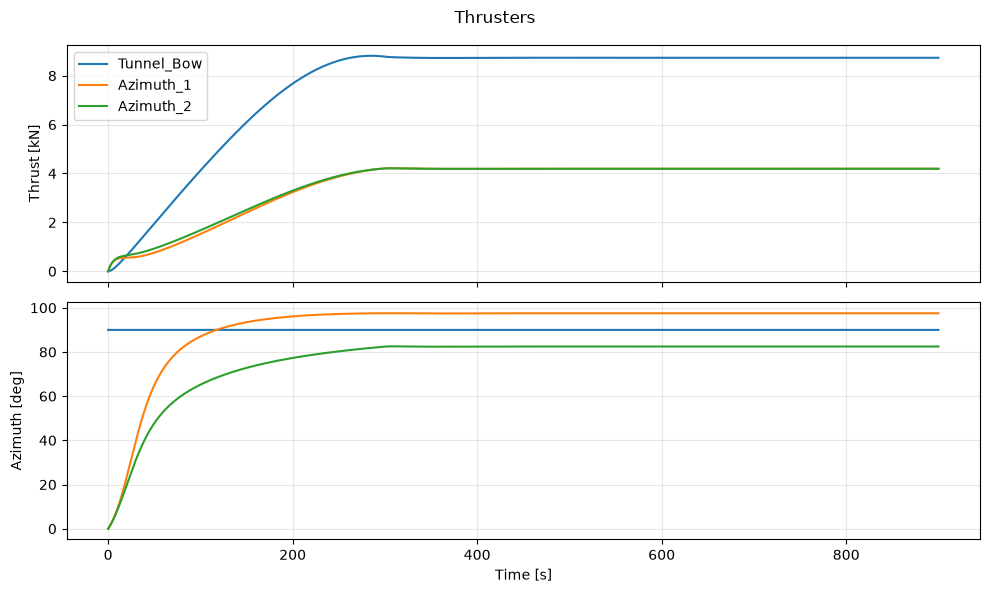

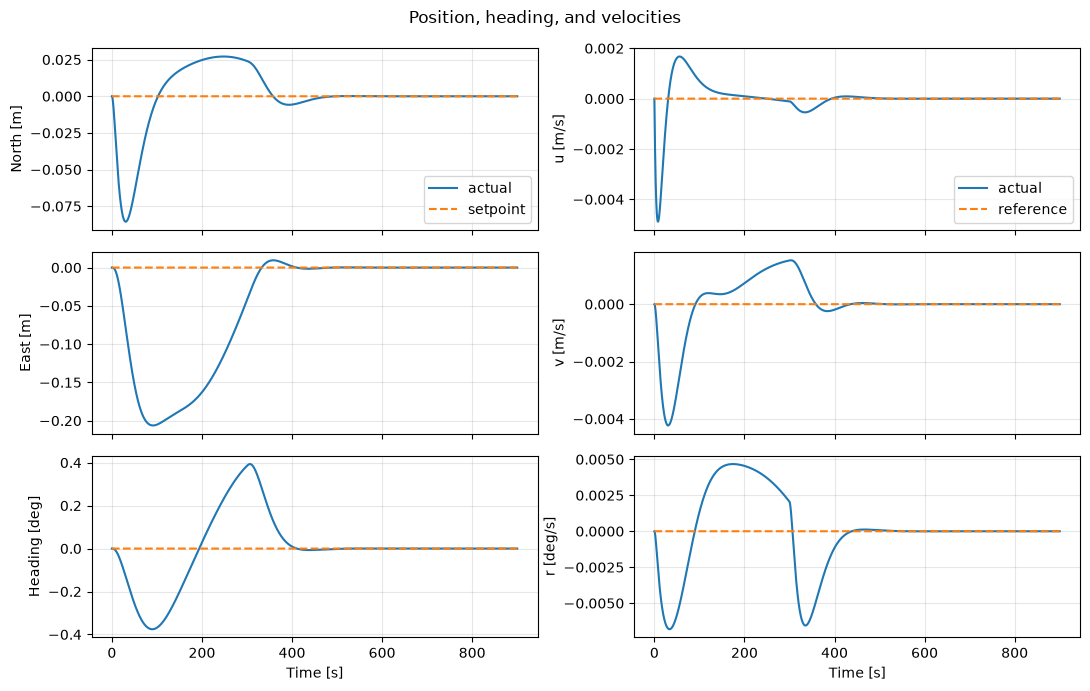

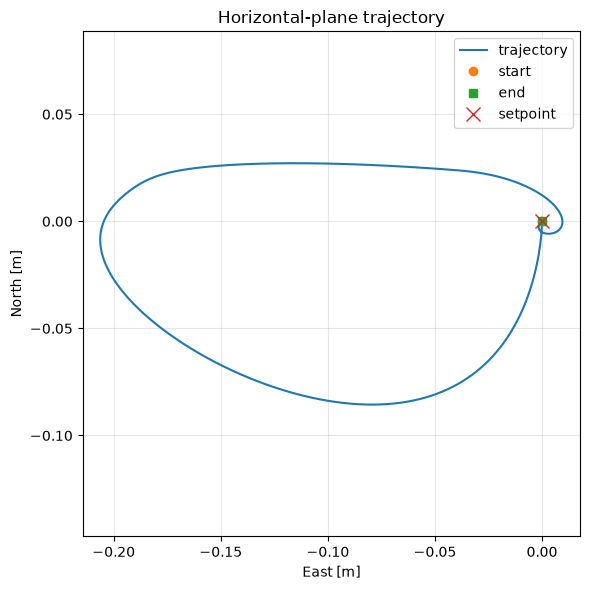

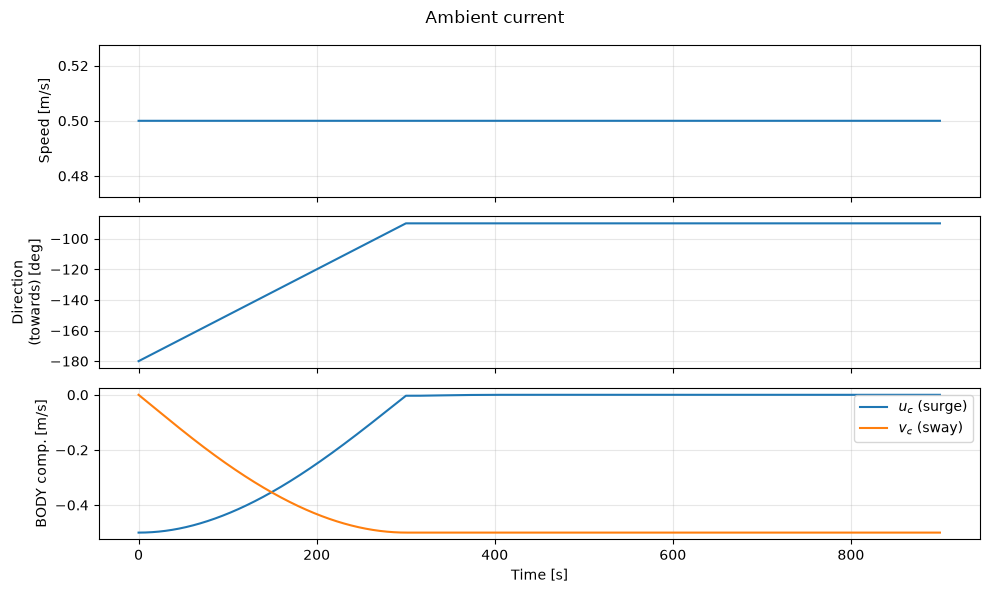

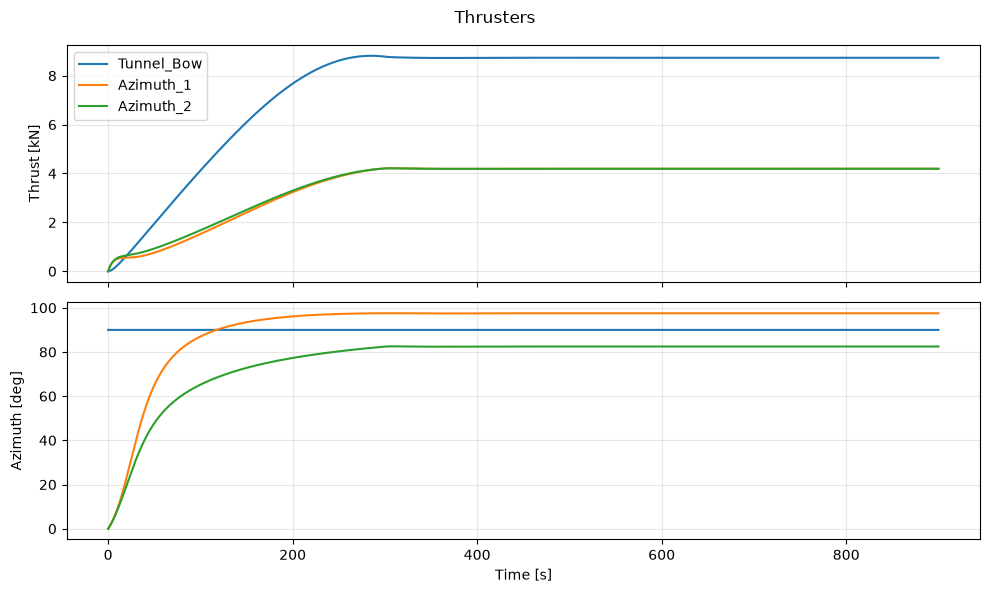

In [7]:
# --- Simulation 2: current rotating from north to east over 300 s ---
current_2 = Current(0.5, 0.0, semantics="from", beta_end=np.pi / 2, duration=300.0)
logs_2 = run_sim(900.0, setpoint(0, 0, 0), current=current_2)

plot_time_histories(logs_2)
plot_xy(logs_2)
plot_current(logs_2)      # the current input — required in the results
plot_thrusters(logs_2)

In [8]:
# Pass/fail criteria for Simulation 2
results["sim2_rotating_current"] = run_check("sim2_rotating_current")
print_result(results["sim2_rotating_current"])

[     PASS      ] Simulation 2: rotating current (north -> east over 300 s)
                  ok    all states finite (no NaN)
                  ok    max position deviation < 5 m  [max 0.21 m]
                  ok    steady-state position error < 1.0 m (last 100 s)  [mean 0.00 m]
                  ok    steady-state heading error < 3 deg  [mean 0.00 deg]


## Simulation 3 — Setpoint Change With and Without Reference Model

From the project text: from $\eta_0 = [0, 0, 0]^\top$, step the setpoint to
$\eta_{sp} = [10, 10, 3\pi/2]^\top$ with no environmental forces, and compare
the response **with and without the reference model** using identical
controller and allocation settings, so the reference-model effect is isolated.

Note the heading command: $3\pi/2$ wraps to $-\pi/2$, so a correct controller
turns $-90°$ (the short way), not $+270°$. Plot position and heading as time
series (including the desired trajectory) and as $xy$-plots; if your reference
model outputs velocities, plot them against the actual velocities. Explain
*why* the reference model changes the response (overshoot, oscillation,
settling time, trajectory smoothness, actuator effort).

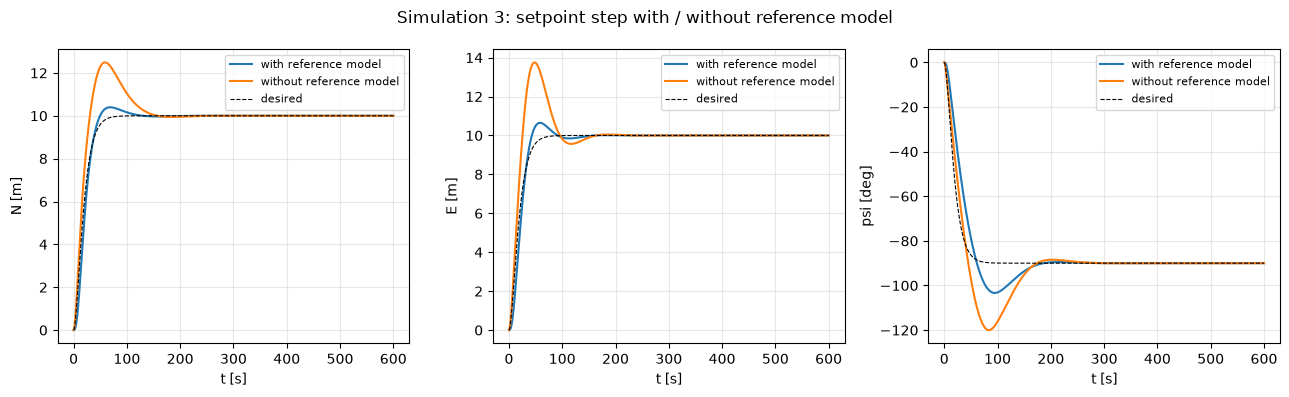

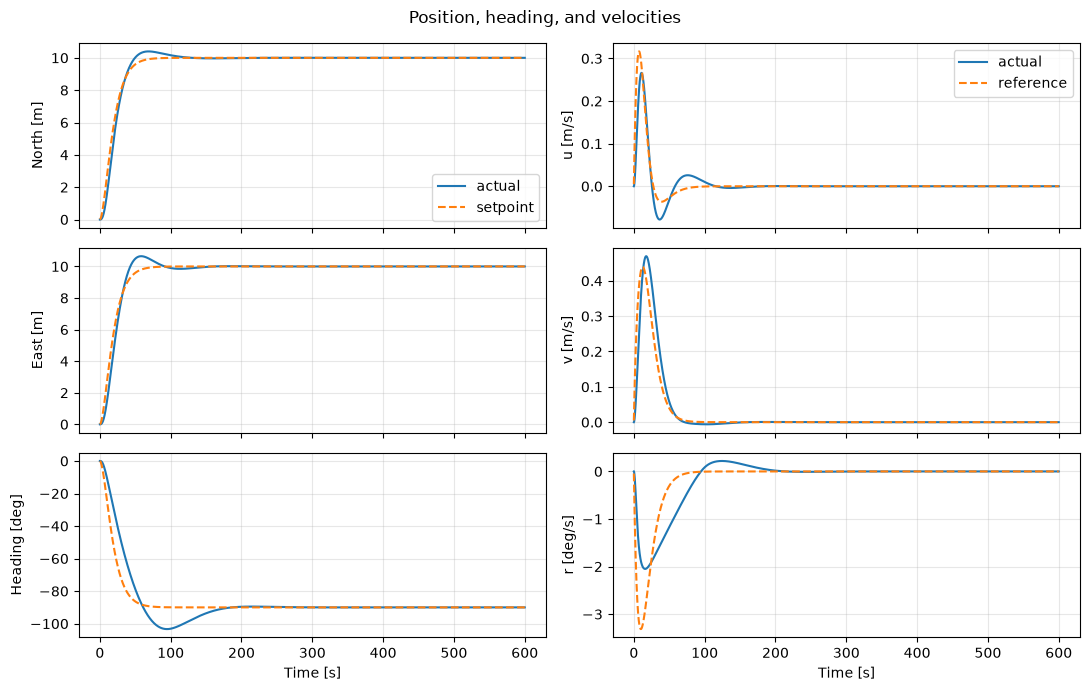

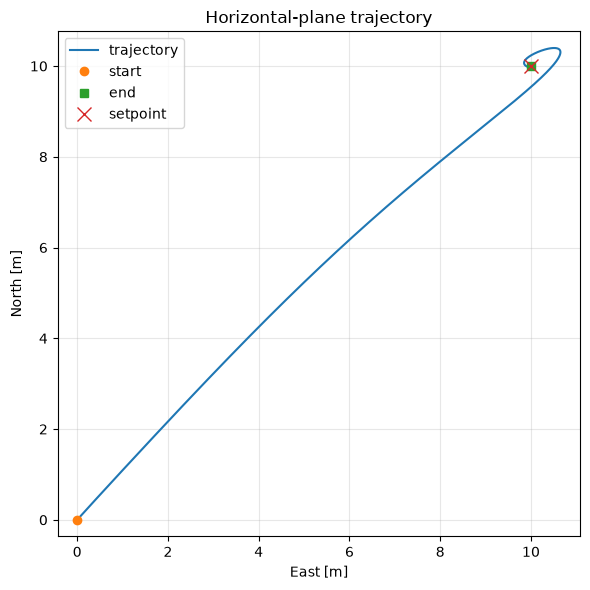

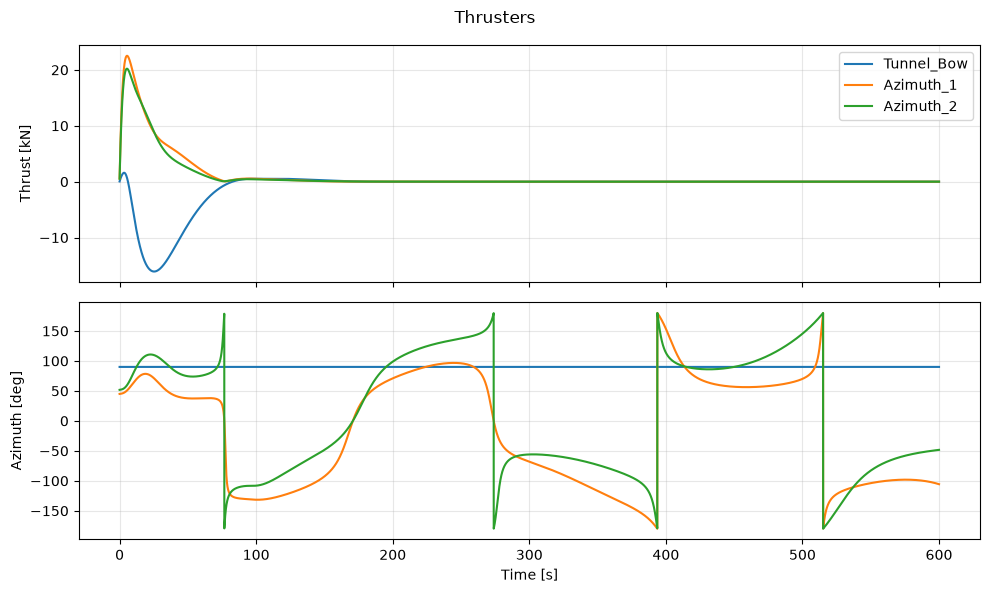

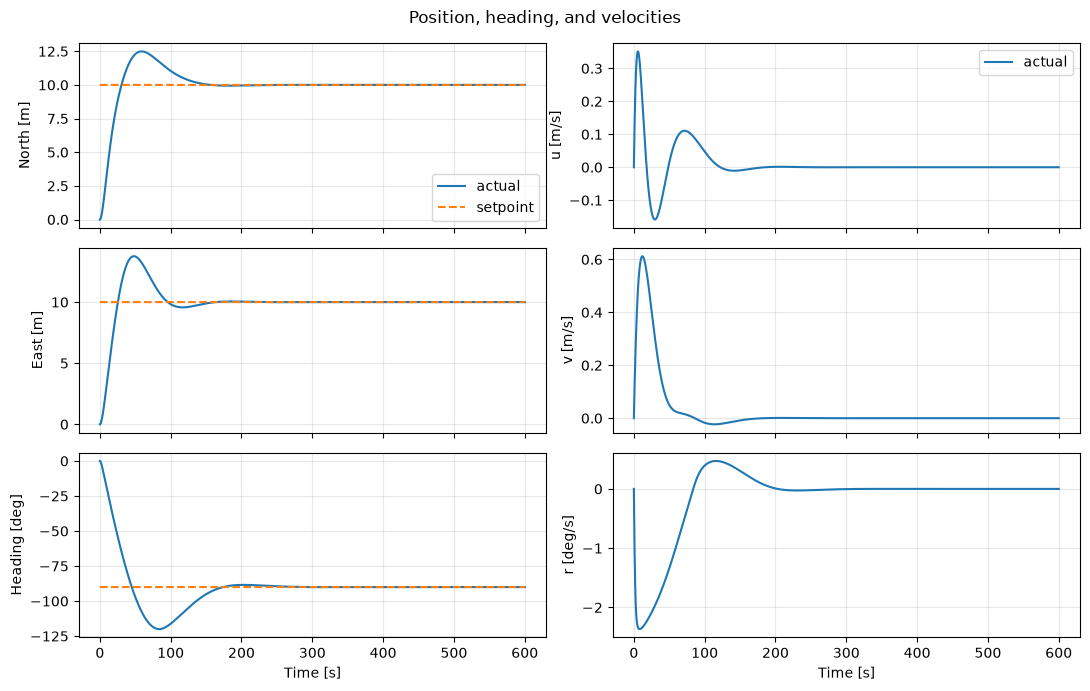

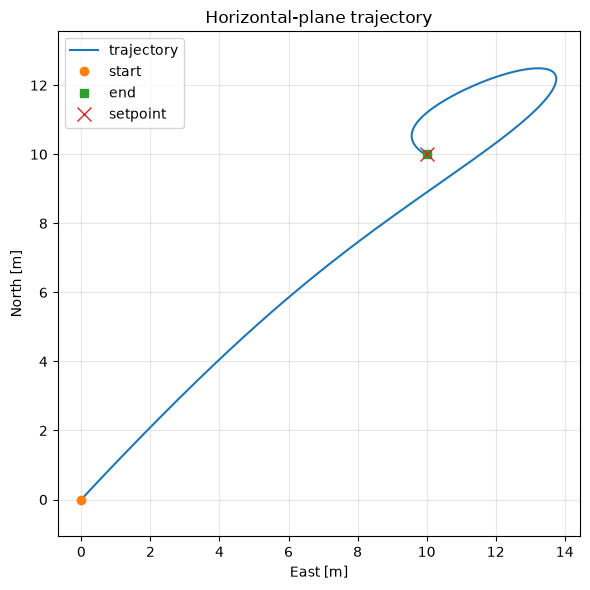

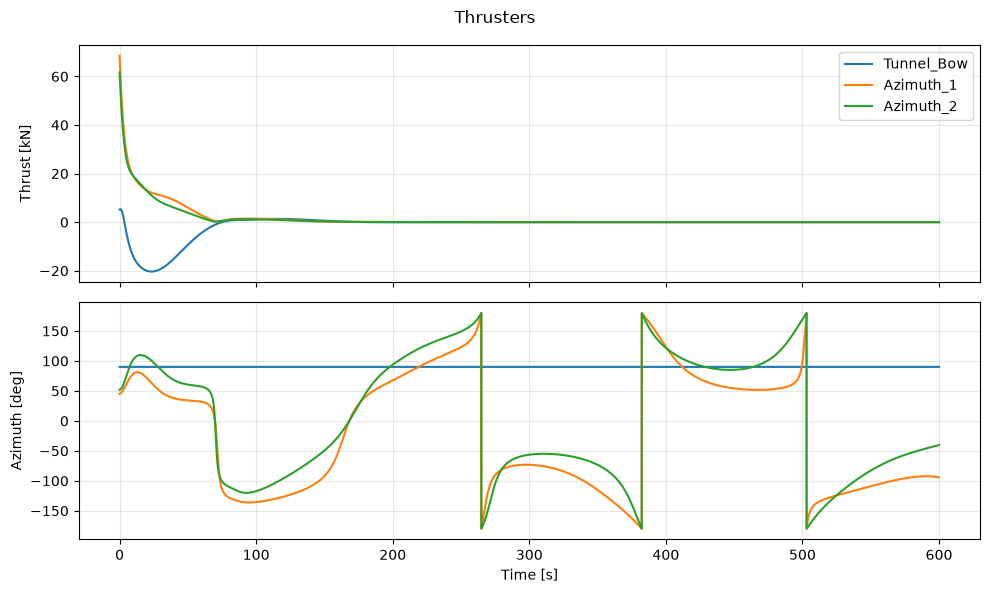

In [9]:
# --- Simulation 3: step to [10, 10, 3*pi/2], with and without reference model ---
target_3 = setpoint(10.0, 10.0, 3.0 * np.pi / 2.0)

logs_3_ref = run_sim(600.0, target_3, use_reference=True)
logs_3_raw = run_sim(600.0, target_3, use_reference=False)

# Direct comparison of the two runs (desired trajectory included)
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
channels = [(0, 'N [m]', 1.0), (1, 'E [m]', 1.0), (5, 'psi [deg]', 180 / np.pi)]
for ax, (idx, label, scale) in zip(axes, channels):
    ax.plot(logs_3_ref.t, scale * logs_3_ref.eta[:, idx], label='with reference model')
    ax.plot(logs_3_raw.t, scale * logs_3_raw.eta[:, idx], label='without reference model')
    ax.plot(logs_3_ref.t, scale * logs_3_ref.sp[:, idx], 'k--', lw=0.8, label='desired')
    ax.set_xlabel('t [s]'); ax.set_ylabel(label); ax.grid(alpha=0.3); ax.legend(fontsize=8)
fig.suptitle('Simulation 3: setpoint step with / without reference model')
fig.tight_layout()

# Full standard plots per run (velocities in the time histories include the
# reference velocities when the reference model provides them)
for label, lg in [('with reference model', logs_3_ref),
                  ('without reference model', logs_3_raw)]:
    plot_time_histories(lg)
    plot_xy(lg)
    plot_thrusters(lg)   # compare the actuator effort between the two runs

In [10]:
# Pass/fail criteria for Simulation 3 (settling with and without reference
# model, overshoot with reference model)
results["sim3_setpoint_change"] = run_check("sim3_setpoint_change")
print_result(results["sim3_setpoint_change"])

[     PASS      ] Simulation 3: setpoint change with/without reference model
                  ok    with reference model: settles at the setpoint (pos err < 0.5 m)  [mean 0.00 m over the last 50 s]
                  ok    with reference model: heading settles (err < 2 deg, wrapped)  [mean 0.00 deg]
                  ok    without reference model: settles at the setpoint (pos err < 0.5 m)  [mean 0.00 m over the last 50 s]
                  ok    without reference model: heading settles (err < 2 deg, wrapped)  [mean 0.00 deg]
                  ok    with reference model: position overshoot < 2 m  [overshoot 0.65 m]


## Simulation 4 — Four-Corner Test

From the project text: with no environmental forces, pass through the
setpoints below **in order**, keeping a steady position at each corner before
moving to the next:

$$\eta_1 = [50, 0, 0],\quad \eta_2 = [50, -50, 0],\quad
\eta_3 = [50, -50, -\pi/4],\quad \eta_4 = [0, -50, -\pi/4],\quad
\eta_5 = [0, 0, 0].$$

The setpoint series below holds each corner for 300 s — check from your plots
that the vessel is settled well before every switch, and increase the hold
time if it is not. `eta_cmd` is a time series of shape `(N_steps, 6)`, one
setpoint row per integration step, built with the same step count as the
engine (`round(T/dt) + 1`). Plot position and heading (with the desired
trajectory) and the $xy$-plot; plot reference velocities against actual
velocities if your reference model provides them.

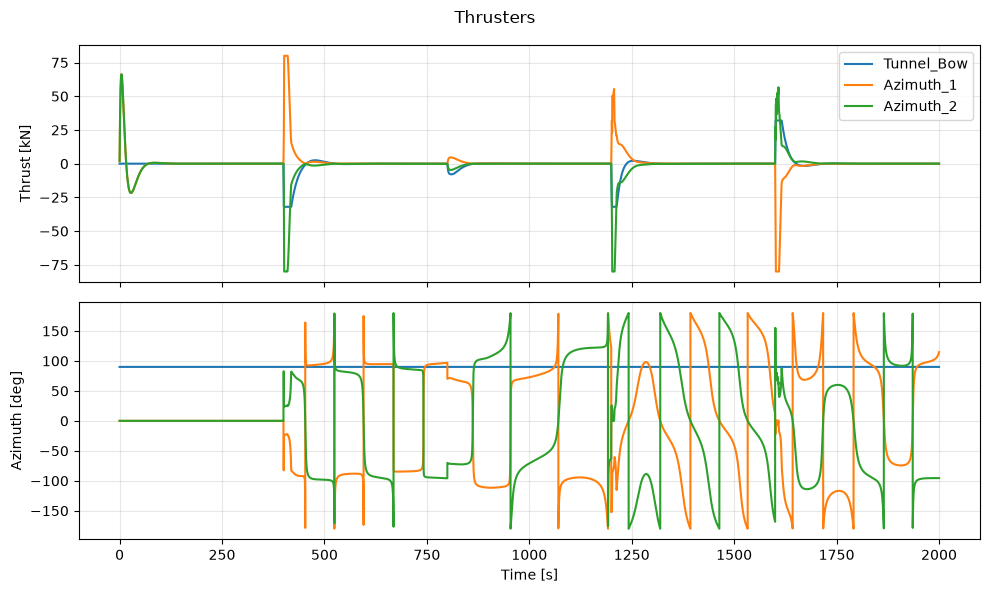

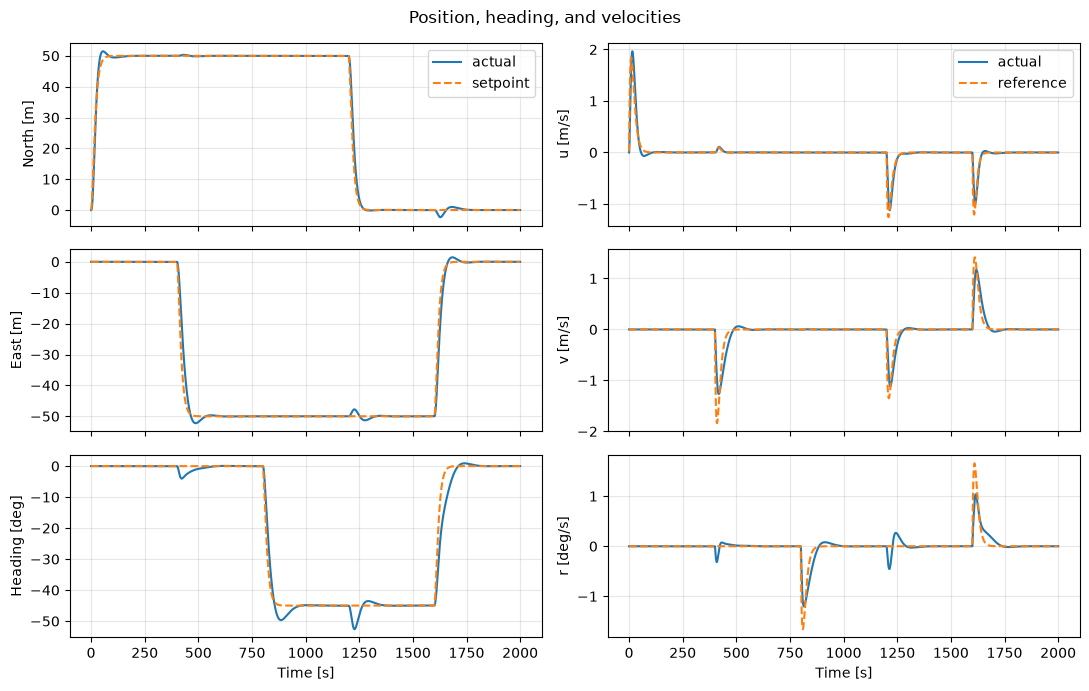

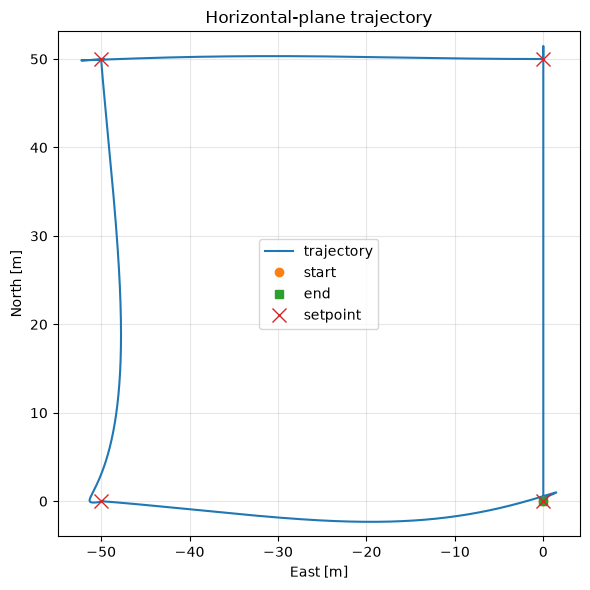

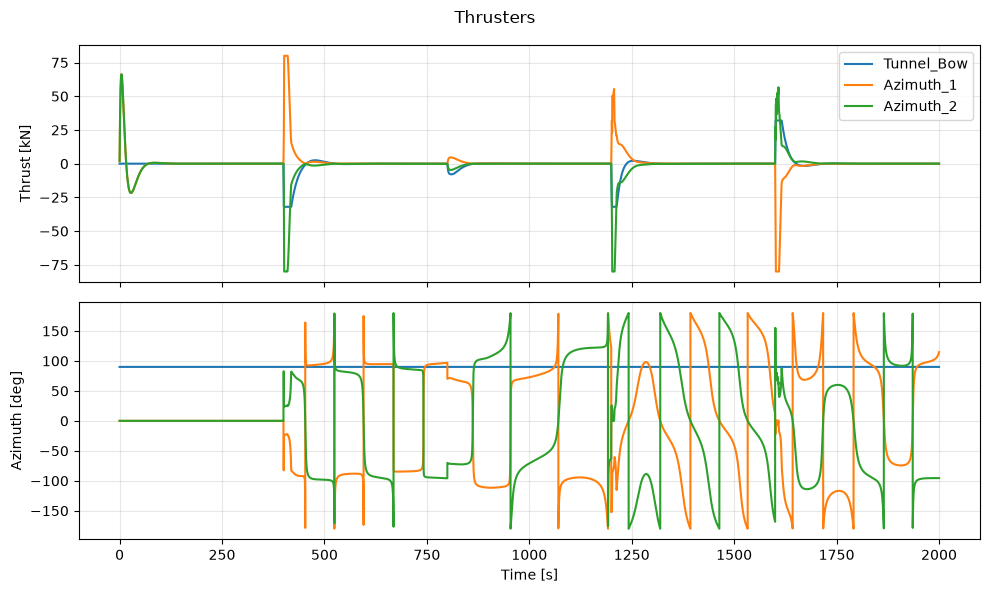

In [11]:
# --- Simulation 4: four-corner test, 300 s per corner ---
corners = [
    (50.0,   0.0,  0.0),
    (50.0, -50.0,  0.0),
    (50.0, -50.0, -np.pi / 4),
    ( 0.0, -50.0, -np.pi / 4),
    ( 0.0,   0.0,  0.0),
]
hold = 400.0                                   # [s] per corner — increase if not settled
dt = SimConfig().dt
T4 = hold * len(corners)

N = int(round(T4 / dt)) + 1                    # same step count as the engine
t4 = np.arange(N) * dt
eta_cmd4 = np.zeros((N, 6))
for i, (n_c, e_c, psi_c) in enumerate(corners):
    rows = t4 >= i * hold
    eta_cmd4[rows, 0], eta_cmd4[rows, 1], eta_cmd4[rows, 5] = n_c, e_c, psi_c

logs_4 = run_sim(T4, eta_cmd4)

plot_time_histories(logs_4)   # desired trajectory is included in the plots
plot_xy(logs_4)
plot_thrusters(logs_4)

In [12]:
# Pass/fail criteria for Simulation 4 (settled at every corner before the switch)
results["sim4_four_corner"] = run_check("sim4_four_corner")
print_result(results["sim4_four_corner"])

[     PASS      ] Simulation 4: four-corner test
                  ok    all states finite (no NaN)
                  ok    eta1 = [50, 0, 0]: settled before the switch (pos err < 1.0 m)  [mean 0.00 m over the last 50 s]
                  ok    eta1 = [50, 0, 0]: heading settled (err < 2 deg)  [mean 0.00 deg]
                  ok    eta2 = [50, -50, 0]: settled before the switch (pos err < 1.0 m)  [mean 0.01 m over the last 50 s]
                  ok    eta2 = [50, -50, 0]: heading settled (err < 2 deg)  [mean 0.01 deg]
                  ok    eta3 = [50, -50, -pi/4]: settled before the switch (pos err < 1.0 m)  [mean 0.00 m over the last 50 s]
                  ok    eta3 = [50, -50, -pi/4]: heading settled (err < 2 deg)  [mean 0.02 deg]
                  ok    eta4 = [0, -50, -pi/4]: settled before the switch (pos err < 1.0 m)  [mean 0.00 m over the last 50 s]
                  ok    eta4 = [0, -50, -pi/4]: heading settled (err < 2 deg)  [mean 0.01 deg]
                  ok    eta5 =

## Check summary

All statuses in one table (re-run the cells above first if you changed code).
When everything below is `PASS`, `python check.py` and `pytest` are green too —
and so is the CI check on your next push.

In [13]:
for key in ALL_CHECKS:
    r = results.get(key)
    print(f"[{r.status if r else 'not run':^15}] {r.name if r else key}")

[     PASS      ] current: direction conventions
[     PASS      ] wind: load signs and relative wind
[     PASS      ] allocation: isolated wrenches
[     PASS      ] controller: sign tests and heading wrap
[     PASS      ] reference model: smooth step and heading wrap
[     PASS      ] Simulation 1a: station keeping in current (0.5 m/s from east)
[     PASS      ] Simulation 1b: station keeping in wind (15 m/s from east)
[     PASS      ] Simulation 2: rotating current (north -> east over 300 s)
[     PASS      ] Simulation 3: setpoint change with/without reference model
[     PASS      ] Simulation 4: four-corner test


## Before the report

- Every figure above needs readable axis labels with units, legends where
  needed, and a **discussion in the text** — what was tested, what behaviour
  was expected, and what the result shows (project text, §8).
- For a reasonably tuned system the maximum position deviation is typically
  around 1–5 m (*Tips*). Much larger deviations usually mean frame/sign
  errors, poor tuning, or allocation problems.
- The checks build your classes with their **default constructors** — keep
  your tuned parameters as the defaults, or the terminal/CI runs
  (`python check.py`, `pytest`) will not see them.
- The appendix of the report must explain how to reproduce these runs.